In [128]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

In [73]:
df = pd.read_csv("Dataset.csv")

print(df.shape)

print(df.isnull().sum())

(9551, 21)
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [74]:
df['Cuisines'].nunique()

1825

In [75]:
print(df['Cuisines'].value_counts().head(20))

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
South Indian                      112
Bakery, Fast Food                 108
Chinese, North Indian             105
Mughlai                           103
Ice Cream, Desserts                83
Ice Cream                          74
North Indian, Fast Food            74
Name: count, dtype: int64


In [76]:
df['Cuisines'].nunique()

print(df['Cuisines'].value_counts().head(20))

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
South Indian                      112
Bakery, Fast Food                 108
Chinese, North Indian             105
Mughlai                           103
Ice Cream, Desserts                83
Ice Cream                          74
North Indian, Fast Food            74
Name: count, dtype: int64


In [77]:
top_cuisines = df['Cuisines'].value_counts().head(10).index

df = df[df['Cuisines'].isin(top_cuisines)]

print(df.shape)
print(df['Cuisines'].value_counts())

(3522, 21)
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [78]:
target = 'Cuisines'

In [79]:
features = [
    'Country Code',
    'City',
    'Average Cost for two',
    'Currency',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu',
    'Price range',
    'Votes'
]

In [80]:
data = df[features + [target]].copy()

In [81]:
le = LabelEncoder()

categorical_cols = [
    'City',
    'Currency',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu'
]

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()

data['Cuisines'] = target_encoder.fit_transform(data['Cuisines'])


In [82]:
X = data.drop('Cuisines', axis=1)

y = data['Cuisines']

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [84]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2817, 10)
(705, 10)
(2817,)
(705,)


In [85]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

c:\Users\ACER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [86]:
print("Accuracy:",
    accuracy_score(y_test, lr_pred))

print(classification_report(
    y_test,
    lr_pred
))

Accuracy: 0.3120567375886525
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.00      0.00      0.00        31
           2       0.67      0.07      0.13        57
           3       0.25      0.03      0.05        75
           4       0.30      0.14      0.19        74
           5       0.32      0.77      0.45       191
           6       0.25      0.32      0.28       100
           7       0.33      0.15      0.21        65
           8       0.00      0.00      0.00        46
           9       0.41      0.56      0.47        25

    accuracy                           0.31       705
   macro avg       0.25      0.20      0.18       705
weighted avg       0.28      0.31      0.23       705



c:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [87]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [88]:
print("Accuracy:",
    accuracy_score(y_test, rf_pred))

print(classification_report(
    y_test,
    rf_pred
))

Accuracy: 0.28794326241134754
              precision    recall  f1-score   support

           0       0.13      0.10      0.11        41
           1       0.12      0.13      0.12        31
           2       0.40      0.51      0.45        57
           3       0.10      0.08      0.09        75
           4       0.27      0.18      0.21        74
           5       0.39      0.50      0.44       191
           6       0.23      0.26      0.25       100
           7       0.26      0.20      0.23        65
           8       0.12      0.09      0.10        46
           9       0.33      0.32      0.33        25

    accuracy                           0.29       705
   macro avg       0.24      0.24      0.23       705
weighted avg       0.27      0.29      0.27       705



In [89]:
lr_acc = accuracy_score(y_test, lr_pred)

rf_acc = accuracy_score(y_test, rf_pred)


comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        rf_acc
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.312057
1,Random Forest,0.287943


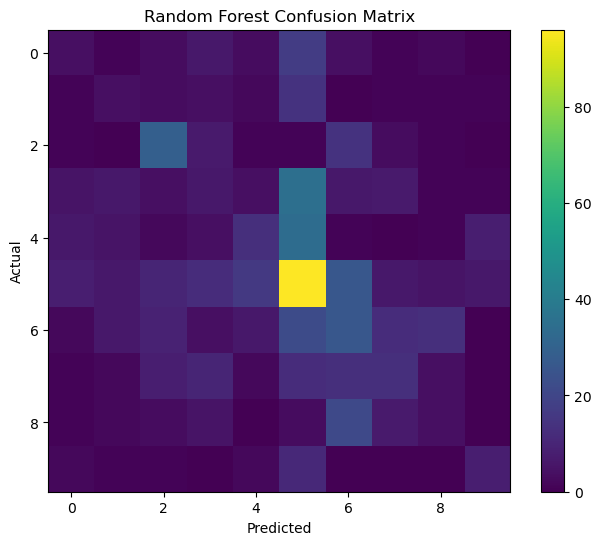

In [90]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [91]:
df['Primary Cuisine'] = df['Cuisines'].apply(
    lambda x: x.split(',')[0].strip()
)

In [92]:
print(df['Primary Cuisine'].value_counts().head(20))

Primary Cuisine
North Indian    1978
Bakery           388
Chinese          354
Fast Food        354
Cafe             299
Street Food      149
Name: count, dtype: int64


In [93]:
print("Unique cuisines:", df['Primary Cuisine'].nunique())

Unique cuisines: 6


In [94]:
top_cuisines = df['Primary Cuisine'].value_counts().head(10).index

df = df[df['Primary Cuisine'].isin(top_cuisines)]

print(df['Primary Cuisine'].value_counts())

Primary Cuisine
North Indian    1978
Bakery           388
Chinese          354
Fast Food        354
Cafe             299
Street Food      149
Name: count, dtype: int64


In [102]:
target = 'Primary Cuisine'

In [103]:
data = df[features + [target]].copy()

In [104]:
le = LabelEncoder()

categorical_cols = [
    'City',
    'Currency',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu'
]

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [105]:
target_encoder = LabelEncoder()

data[target] = target_encoder.fit_transform(data[target])

In [106]:
print(data[target].nunique())
print(data[target].unique())

6
[2 1 0 3 4 5]


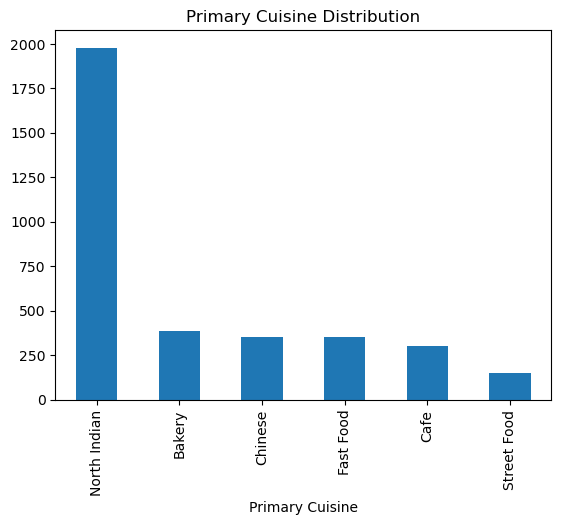

In [121]:
df['Primary Cuisine'].value_counts().plot(kind='bar')
plt.title('Primary Cuisine Distribution')
plt.show()

In [108]:
X = data.drop(target, axis=1)
y = data[target]

In [109]:
print(y.head())

5     2
23    1
24    0
88    3
93    2
Name: Primary Cuisine, dtype: int64


In [111]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [112]:
X_train_scaled
X_test_scaled

array([[-0.10198539,  0.40507818, -0.42403572, ...,  0.        ,
        -0.73981757, -0.28985292],
       [-0.10198539, -1.48592996,  0.33704018, ...,  0.        ,
         0.65513966, -0.01774601],
       [-0.10198539,  0.40507818, -0.7502111 , ...,  0.        ,
        -0.73981757, -0.18019789],
       ...,
       [-0.10198539, -1.84049399,  0.01086479, ...,  0.        ,
         0.65513966, -0.11521714],
       [-0.10198539,  0.40507818, -0.42403572, ...,  0.        ,
        -0.73981757, -0.24923995],
       [-0.10198539,  0.40507818, -0.85893623, ...,  0.        ,
        -0.73981757,  0.02692826]], shape=(705, 10))

In [113]:
print(data[target].unique())
print(y.head())

[2 1 0 3 4 5]
5     2
23    1
24    0
88    3
93    2
Name: Primary Cuisine, dtype: int64


In [114]:
X = data.drop(target, axis=1)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [116]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [117]:
lr = LogisticRegression(max_iter=3000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [118]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [119]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy:
0.5702127659574469
Random Forest Accuracy:
0.5234042553191489


In [134]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [0.5702, 0.5234]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.5702
1,Random Forest,0.5234


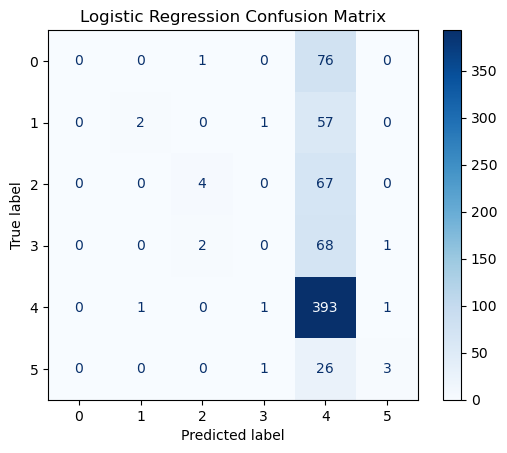

In [131]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

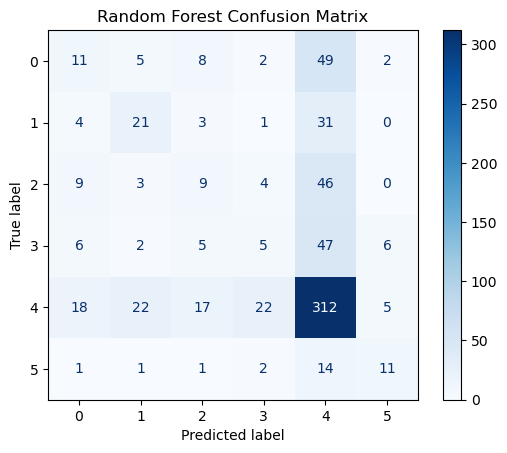

In [133]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [135]:
improvement = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Before':[0.3121,0.2879],
    'After':[0.5702,0.5234]
})

improvement

,Model,Before,After
0,Logistic Regression,0.3121,0.5702
1,Random Forest,0.2879,0.5234
